In [1]:


!pip install textblob pandas matplotlib


========== OPINION MINING RESULTS ==========

                                            Review Sentiment  Polarity
    The product is excellent and very easy to use.  Positive  0.781667
           I am extremely happy with this product.  Positive  0.800000
     The quality is amazing and delivery was fast.  Positive  0.400000
    Great product with excellent customer service.  Positive  0.900000
              I really enjoyed using this product.  Positive  0.500000
      The product is terrible and stopped working.  Negative -1.000000
      Very poor quality and disappointing service.  Negative -0.560000
                    I am unhappy with the product.  Negative -0.600000
The delivery was late and the product was damaged.  Negative -0.300000
                Worst customer service experience.  Negative -1.000000
                              The product is okay.  Positive  0.500000
                          The service was average.  Negative -0.150000
               Delivery was nei

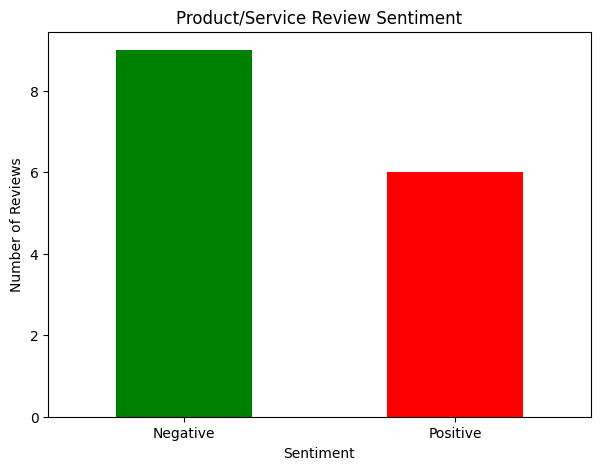

In [2]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Create a sample Product/Service Reviews Dataset
# ---------------------------------------------------

data = {
    "Review": [
        "The product is excellent and very easy to use.",
        "I am extremely happy with this product.",
        "The quality is amazing and delivery was fast.",
        "Great product with excellent customer service.",
        "I really enjoyed using this product.",

        "The product is terrible and stopped working.",
        "Very poor quality and disappointing service.",
        "I am unhappy with the product.",
        "The delivery was late and the product was damaged.",
        "Worst customer service experience.",

        "The product is okay.",
        "The service was average.",
        "Delivery was neither fast nor slow.",
        "The product works as expected.",
        "It is an ordinary product."
    ]
}

df = pd.DataFrame(data)

# ---------------------------------------------------
# 2. Function for sentiment analysis
# ---------------------------------------------------

def get_sentiment(review):

    polarity = TextBlob(review).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


# ---------------------------------------------------
# 3. Apply opinion mining
# ---------------------------------------------------

df["Sentiment"] = df["Review"].apply(get_sentiment)

# Calculate polarity
df["Polarity"] = df["Review"].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

# ---------------------------------------------------
# 4. Display results
# ---------------------------------------------------

print("========== OPINION MINING RESULTS ==========\n")

print(df.to_string(index=False))

# ---------------------------------------------------
# 5. Count sentiments
# ---------------------------------------------------

sentiment_counts = df["Sentiment"].value_counts()

print("\n========== SENTIMENT SUMMARY ==========\n")

print(sentiment_counts)

# ---------------------------------------------------
# 6. Calculate percentages
# ---------------------------------------------------

total = len(df)

print("\n========== SENTIMENT PERCENTAGE ==========\n")

for sentiment, count in sentiment_counts.items():

    percentage = (count / total) * 100

    print(
        sentiment,
        ":",
        count,
        "reviews",
        "(",
        round(percentage, 2),
        "%)"
    )

# ---------------------------------------------------
# 7. Plot sentiment distribution
# ---------------------------------------------------

plt.figure(figsize=(7, 5))

sentiment_counts.plot(
    kind="bar",
    color=["green", "red", "gray"]
)

plt.title("Product/Service Review Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()
